In [1]:
import numpy as np

import matplotlib.pyplot as plt
#from scipy.integrate import odeint
#import mpmath as mpmath
#from scipy.optimize import linear_sum_assignment  # Hungarian algorithm 
import scipy

plt.rc('text', usetex=True)

# %matpnlotlib notebook 
%matplotlib inline 

import Husimi   # Quantum routines is used here! Uprop2 routine
#import Harp     # Classical integration routines
import importlib  # for reloading routines if you need to edit them

import pickle  # for storing python classes in binary files 

With fixed mu/epsilon, vary sqrt{a epsilon}
vary N
allow phishift 
allow NPpower
allow Deltab
allow iterations 
vary Delta mu

 we look at k=1 frame potential statistic from a sample of unitaries generated with various recipes
then do ks test with the exp distribution.  Most experiments fail the ks test (null hypothesis is rejected!), 
but unitaries with Haar pass it (good check!)  Next we need to try drifting systems to see if they are better.
Prob distributions look good but fail tests. 
Note that is not the same thing as passing a mean test.  These distributions could still be k-designs for low k. 
The ks test is definitive for saying the probabilities distributions are different. Not specifying that they 
have equivalent means. Chances are the means are not the same though as the z values tend to be high. 

In [2]:
froot = 'Iter01_'

In [3]:
#rng = np.random.default_rng()
#np.random.seed(1)   # if we want to seed it!

# given a list of matrices Ulist
# compute z = |tr (U V^dagger)|^2 for consecutive pairs of them 
# returns a list of z values that is half as long as original list of matrices 
# calls perrs()
def kone(Ulist):
    N_u = Ulist.shape[0]
    zlist = np.zeros(0)
    for k in range(0,N_u,2):
        #print(k)
        U = np.squeeze(Ulist[k,:,:])
        V = np.squeeze(Ulist[k+1,:,:])
        Vdagger = V.conj().T
        UVdagger = np.matmul(U,Vdagger)
        z = np.abs( np.linalg.trace(UVdagger))**2
        zlist = np.append(zlist,z)
        
    res = perrs(zlist,'kone1')  # computes stats 
    return zlist, res

# print stuff and return a list of stats from a list of values 
# calls cdf_exp()
def perrs(zlist,prefix):
    N_z = len(zlist)
    res = scipy.stats.kstest(zlist,cdf_exp);  res_2s = res.pvalue
    print(prefix,"twosided pvalue={:.3f}".format(res.pvalue))
    res = scipy.stats.kstest(zlist,cdf_exp,alternative='less');    res_l = res.pvalue  
    print(prefix,"lower pvalue={:.3f}".format(res.pvalue))
    res = scipy.stats.kstest(zlist,cdf_exp,alternative='greater'); res_g = res.pvalue
    print(prefix,"greater pvalue={:.3f}".format(res.pvalue))
    # If below 0.05 null hyp is rejected and that's bad

    mm = np.mean(zlist); sig = np.std(zlist); std_err = sig/np.sqrt(N_z)
    print(prefix,"mean z ={:.3f} += {:.3f}, std z = {:.2f}".format(mm, std_err, sig ))
    
    z2list = zlist**2  # take the square for computing means k=2
    mm_2 = np.mean(z2list); sig_2 = np.std(z2list); std_err_2 = sig_2/np.sqrt(N_z)
    print(prefix,"mean z2 ={:.3f} += {:.3f}, std z2 = {:.2f}".format(np.mean(z2list), np.std(z2list)/np.sqrt(N_z), np.std(z2list) ))
    print("")
    return np.array([ res_2s, res_l, res_g, mm, std_err, sig, mm_2, std_err_2,sig_2])
    # res_2s is a twosided pvalue, from ks test with exponential distribution 
    # res_l is a lower pvalue
    # rels_g is a greater pvalue
    # mm is the mean
    # std_err is the standard error
    # sig is the standard deviation computed from the sample 
    # mm_2 is the mean of z^2
    # std_err_2 is the standard error of z^2
    # sig_2 is the standard deviation from the sample of z^2
       
# same as above kone routine but doing all possible pairs from the list of unitaries
# calls perrs()
def kone2(Ulist):
    N_u = Ulist.shape[0]
    zlist = np.zeros(0)
    for k in range(0,N_u-1,1):
        for j in range(k+1,N_u,1):
            #print(k)
            U = np.squeeze(Ulist[k,:,:])
            V = np.squeeze(Ulist[j,:,:])
            Vdagger = V.conj().T
            UVdagger = np.matmul(U,Vdagger)
            z = np.abs( np.linalg.trace(UVdagger))**2
            zlist = np.append(zlist,z)
            
    res= perrs(zlist,'kone2')
    return zlist,res

# cummulative probability density distribution for exponential distribution 
def cdf_exp(x):  
    return 1- np.exp(-x)


# plots two sets of cummulative distributions 
def plt_stuff(zlist1,zlist2):
    fig,axarr = plt.subplots(1,2,figsize=(5,3),sharex = True,sharey=True)
    plt.subplots_adjust(bottom=0.1,top=0.98,right=0.99,left=0.1,wspace=0,hspace=0)
    axarr[0].hist(zlist1,bins=160,density=True,range=[0,40],cumulative=True)  
    #  chop range otherwise you have a large one that screw up the bins
    axarr[0].set_xlim([0,10])
    x1,x2 = axarr[0].get_xlim()
    xlin = np.linspace(0,x2,30)
    axarr[0].plot(xlin,1-np.exp(-1*xlin), '-', label = r'$1-e^{-z}$')  # com distrubution is 1-exponential
    axarr[0].set_ylabel('probability')
    axarr[0].set_xlabel(r'|tr ($UV^\dagger$)|$^2$')
    axarr[0].legend(loc='lower right')

    axarr[1].hist(zlist2,bins=160,density=True,range=[0,40],cumulative=True)
    axarr[1].plot(xlin,1-np.exp(-1*xlin), '-', label = r'$1-e^{-z}$')  
    #ax.set_ylabel('probability')
    axarr[1].set_xlabel(r'|tr ($UV^\dagger$)|$^2$')
    #axarr[1].legend()
    plt.show()  

# only plots one list of cummulative distns?
def plt_stuff1(zlist1,tlabel,ofile):
    fig,ax = plt.subplots(1,1,figsize=(3,3),sharex = True,sharey=True,dpi=200)
    plt.subplots_adjust(bottom=0.1,top=0.98,right=0.99,left=0.1,wspace=0,hspace=0)
    ax.hist(zlist1,bins=160,density=True,range=[0,40],cumulative=True,alpha=0.5)  
    #  chop range otherwise you have a large one that screw up the bins
    ax.set_xlim([0,10])
    x1,x2 = ax.get_xlim()
    xlin = np.linspace(0,x2,30)
    ax.plot(xlin,1-np.exp(-1*xlin), '-', label = r'$1-e^{-z}$')  # com distrubution is 1-exponential
    ax.set_ylabel('probability')
    ax.set_xlabel(r'$|\mathrm{tr} (UV^\dagger)|^2$')
    ax.legend(loc='lower right')

    #axarr[1].hist(zlist2,bins=160,density=True,range=[0,40],cumulative=True)
    #axarr[1].plot(xlin,1-np.exp(-1*xlin), '-', label = r'$1-e^{-z}$')  
    #ax.set_ylabel('probability')
    #axarr[1].set_xlabel(r'|tr ($UV^\dagger$)|$^2$')
    #axarr[1].legend()
    ax.text(0.5,0.5,tlabel,transform=ax.transAxes)
    if (len(ofile)>2):
        plt.savefig(ofile)
    plt.show()  



In [4]:
# control case of unitaries, Haar uniformly distributed using scipy's routine
# which is based on F. Mezzadri, “How to generate random matrices from the classical compact groups”, arXiv:math-ph/0609050v2
# arguments:
#  N  dimension of matrices
#  N_u how many matrices to compute
#  seed:  if you want the same random sequence, then pass an integer>0 as the seed 
# returns:
#  a list of random Haar distributed unitary matrices  in a 3d array N_u x N x N
def Ulist_Harr(N,N_u,seed=None):
    
    Ulist = np.zeros((N_u, N,N), dtype = complex)
    if (seed == None):
        for k in range(N_u):
            U = scipy.stats.unitary_group.rvs(N)
            Ulist[k,:,:] = U
    else:
        rs = np.random.RandomState(seed)
        for k in range(N_u):
            U = scipy.stats.unitary_group.rvs(N,random_state=rs)
            Ulist[k,:,:] = U
    return Ulist


In [5]:

# a class just to store information about a random series of iterates
# parms = np.array([N,N_u,a,eps,b0,mu0,mup0,Delta_mu,Delta_mup,Delta_b,Delta_taushift])
class Floq_vals():
    def __init__(self,parms,seed=None):
        self.parms = parms
        self.N = int(self.parms[0] + 1e-6)  # dimension 
        self.N_u = int(self.parms[1] + 1e-6) # numbers of iterates
        # allocate memory for stuff 
        self.taushiftlist = np.zeros(self.N_u)
        self.mulist = np.zeros(self.N_u)  # actual values used (randomly generated)
        self.muplist = np.zeros(self.N_u)
        self.blist =  np.zeros(self.N_u)
        self.Ulist = np.zeros((self.N_u, self.N,self.N), dtype = complex)  # to store output unitaries 
        self.seed = seed
        # init does not compute anything!

    def comp_kone(self):
        zlist, res = kone(self.Ulist) # compute the matrices and |tr UV^\dagger|^2  from pairs of matrices
        self.zlist = zlist
        self.res = res 

# a trial recipe for making random matrices 
# arguments: 
#    parms: is an array of parameters  
#    seed:  if passed then use this integer to seed the random number generator
# parms contains the following 
# 0  N dimension of quantum space
# 1  N_u number of unitaries produced by iterator
# 2  a:  fixed
# 3  b0:  fixed, base value for b
# 4  eps: fixed
# 5  mu0:  base value for mu
# 6  mup: base value for mup
# 7  Delta_mu : width of uniform add-on for mu
# 8  Delta_mup : width of uniform add-on for mup
# 9  Delta_b : width of uniform add-on for b 
# 10  Delta_taushift : width of uniform add-on for taushift
# returns:
#   a class (Floq_vals type) holding list of NxN complex unitaries in a 3 dim matrix of size [N_u,N,N]
#       and holds lists of actual parameter values used to create each unitary 
# calls: Husimi.U_prop2(), Floq_vals class def
def rec1(parms,seed=None):
    N = int(parms[0] + 1e-6)
    N_u = int(parms[1] + 1e-6)
    a = parms[2]
    b0 = parms[3]
    eps = parms[4]
    mu0 = parms[5]
    mup0 = parms[6]
    
    Delta_mu = parms[7]
    Delta_mup = parms[8]
    Delta_b = parms[9]
    Delta_taushift = parms[10]

    if (seed == None):
        Fvals = Floq_vals(parms)  # creates a class to hold stuff
    else: 
        Fvals = Floq_vals(parms,seed) 
        rs = np.random.RandomState(seed) # seed the random number generator if you want results to be repeatable
    
    ntau = N*4

    for k in range(N_u):
        # choose parameters 
        if (seed == None):
            taushift = Delta_taushift*scipy.stats.uniform.rvs();  # random phase shift
            mu = mu0 + Delta_mu*scipy.stats.uniform.rvs(); 
            mup = mup0 + Delta_mup*scipy.stats.uniform.rvs(); 
            b = b0 + Delta_b*scipy.stats.uniform.rvs();
        else:
            taushift = Delta_taushift*scipy.stats.uniform.rvs(random_state=rs);  # random phase shift
            mu = mu0 + Delta_mu*scipy.stats.uniform.rvs(random_state=rs); 
            mup = mup0 + Delta_mup*scipy.stats.uniform.rvs(random_state=rs); 
            b = b0 + Delta_b*scipy.stats.uniform.rvs(random_state=rs);
        
        w,vr,U = Husimi.U_prop2(N,ntau,a,b,eps,mu,mup,taushift) # create U

        # store stuff 
        Fvals.Ulist[k,:,:] = U  
        Fvals.taushiftlist[k] =  taushift
        Fvals.mulist[k]  =  mu
        Fvals.muplist[k] =  mup
        Fvals.blist[k]   =  b

    Fvals.comp_kone()  # compute stats and zlist
        
    return Fvals



In [6]:
# take the output of the series of runs we just did and create 
# arrays that we can plot 
# arguments:  a Floq_vals class
def mkmmlist(Fvals_list):
    NFv = len(Fvals_list)
    mm_list = np.zeros(NFv)
    std_err_mm = np.zeros(NFv)
    mm2_list = np.zeros(NFv)
    std_err_mm2 = np.zeros(NFv)
    for k in range(NFv):  
        #[ res_2s, res_l, res_g, mm, std_err, sig, mm_2, std_err_2,sig_2 ])
        #  0        1        2    3    4        5     6    7        8
        mm_list[k] = Fvals_list[k].res[3]
        std_err_mm[k] = Fvals_list[k].res[4]
        mm2_list[k] = Fvals_list[k].res[6]
        std_err_mm2[k] = Fvals_list[k].res[7]
    return mm_list,std_err_mm, mm2_list,std_err_mm2

kone1 twosided pvalue=0.015
kone1 lower pvalue=0.008
kone1 greater pvalue=0.919
kone1 mean z =1.048 += 0.026, std z = 1.02
kone1 mean z2 =2.138 += 0.117, std z2 = 4.54



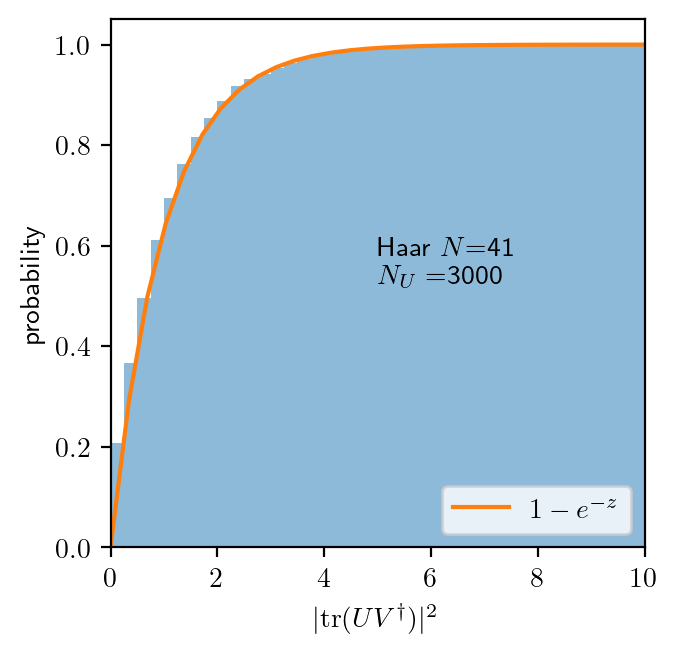

In [7]:
# control case, Haar
N=41; N_u = 3000
UlistH = Ulist_Harr(N,N_u)  # no seed chosen here but routine allows it
zlist_H,res_H = kone(UlistH)
#zlist2_H,res2_H = kone2(UlistH)

#plt_stuff(zlist_H,zlist2_H)
#  notice that the pvalue is much lower in the all pairs even for unitary!
# so probably it is a bad idea to use all pairs 
Nlabel = r'Haar $N$=' + f'{N}'  +'\n' + r'$N_U=$' + f'{N_u}'
plt_stuff1(zlist_H,Nlabel,froot+'cdf_har.png')

kone1 twosided pvalue=0.278
kone1 lower pvalue=0.847
kone1 greater pvalue=0.140
kone1 mean z =0.975 += 0.031, std z = 0.99
kone1 mean z2 =1.933 += 0.140, std z2 = 4.43



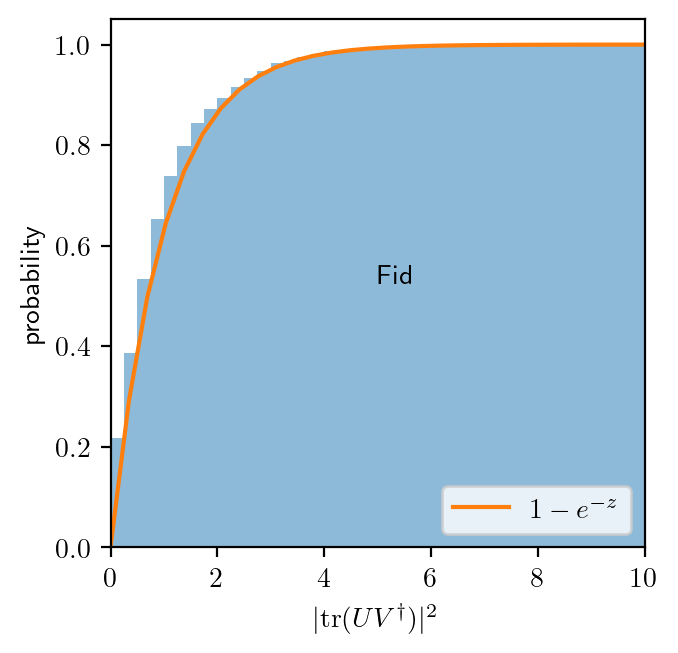

In [8]:
# base or fiducial values 
a = 3.0; eps=a; b0=0; mu0 = a; mup0 = a
# uniform widths:
Delta_mu = 2.7; Delta_mup =0.2; Delta_b=2*np.pi; Delta_taushift = 2*np.pi
N=41; N_u = 2000  # dimension and number of Us in list 
parms_a = np.array([N,N_u,a,b0,eps,mu0,mup0,Delta_mu,Delta_mup,Delta_b,Delta_taushift])
Fvals_a = rec1(parms_a,seed=2)  # compute a set of unitaries class of outputs, including values used, notice seeding!
plt_stuff1(Fvals_a.zlist,'Fid','')


In [9]:
# how I did the check to figure out what was causing extreme values
#plt.hist(Fvals_a.zlist,bins=100)
#plt.show()
# there is a high value of about 137
#print(np.argmax(Fvals_a.zlist ))
#k = np.argmax(Fvals_a.zlist)
#print(Fvals_a.zlist[k])  # to find the values we had at the large value 

#print(Fvals_a.mulist[2*k],Fvals_a.mulist[2*k+1])
#print(Fvals_a.muplist[2*k],Fvals_a.muplist[2*k+1])
#print(Fvals_a.taushiftlist[2*k],Fvals_a.taushiftlist[2*k+1])
#print(Fvals_a.blist[2*k],Fvals_a.blist[2*k+1])
#These two are close together, they are the ones causing a high value
# I check the surface of section of one of them and it was featureless.
# I conclude that the reason we see high points is that 
# the probability of a similar U depends on the proximity of randomly chosen points. 
# the randomly chosen points are a much smaller dimension than U(N) and that 
# means we have a moderate probability of getting an outlier
# there is some distance we need in the randomly chosen parameters in order to 
# have a chance of getting close 
# so our question on this issue is answered

############## don't delete this! as it is a record of a test I did

In [10]:
# do a series fid but varying N, based on parms_a
Nlist = np.array([15,30,45,60,75]) 
seed_list = np.array([3,4,5,6,7],dtype = int)
Fvals_list = []
for k in range(len(Nlist)):
    parms = np.copy(parms_a)
    parms[0] = Nlist[k]
    print(Nlist[k])
    Fvals = rec1(parms,seed=seed_list[k])
    Fvals_list = np.append(Fvals_list,Fvals)


15
kone1 twosided pvalue=0.578
kone1 lower pvalue=0.830
kone1 greater pvalue=0.297
kone1 mean z =1.056 += 0.057, std z = 1.81
kone1 mean z2 =4.407 += 2.108, std z2 = 66.65

30
kone1 twosided pvalue=0.558
kone1 lower pvalue=0.286
kone1 greater pvalue=0.709
kone1 mean z =1.048 += 0.034, std z = 1.07
kone1 mean z2 =2.239 += 0.151, std z2 = 4.78

45
kone1 twosided pvalue=0.153
kone1 lower pvalue=0.076
kone1 greater pvalue=0.831
kone1 mean z =1.043 += 0.034, std z = 1.06
kone1 mean z2 =2.219 += 0.232, std z2 = 7.33

60
kone1 twosided pvalue=0.928
kone1 lower pvalue=0.552
kone1 greater pvalue=0.786
kone1 mean z =1.035 += 0.034, std z = 1.07
kone1 mean z2 =2.222 += 0.165, std z2 = 5.22

75
kone1 twosided pvalue=0.891
kone1 lower pvalue=0.511
kone1 greater pvalue=0.690
kone1 mean z =1.002 += 0.033, std z = 1.04
kone1 mean z2 =2.082 += 0.180, std z2 = 5.68



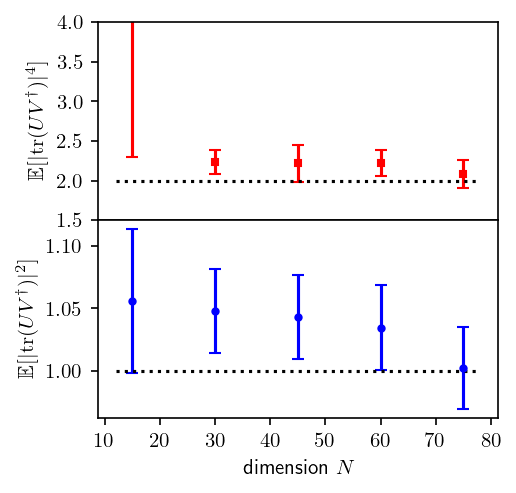

In [11]:
# make a figure comparing Frame potentials
# arguments:
#   Fvals_list: is a class holding of all the output data
#   xarr: xaxis data for the plot 
#   xlabel:  axix label  latex string
#   ofile: output png file name
#   y0low,y0high,y1low,y1high: y limits of the two panels
# outputs: none, though make a figure 
def mk_tr_fig(Fvals_list,xarr,xlabel,ofile,y0low=None,y0high=None,y1low=None,y1high=None):
    #[ res_2s, res_l, res_g, mm, std_err, sig, mm_2, std_err_2,sig_2 ])
    mm_list,std_err_mm, mm2_list,std_err_mm2= mkmmlist(Fvals_list)
    fig,axarr = plt.subplots(2,1,figsize=(3,3),dpi=150,sharex=True)
    plt.subplots_adjust(bottom=0.1,top=0.98,left=0.1,right=0.99,wspace=0,hspace=0)
    plt.rcParams.update({
        'font.size': 8,
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsfonts}'
    })

    axarr[1].errorbar(xarr,mm_list,std_err_mm,capsize=3, markersize=3,color='blue',fmt='o')
    axarr[0].errorbar(xarr,mm2_list,std_err_mm2,capsize=3, markersize=3,color='red',fmt='s')
    x1,x2 = axarr[0].get_xlim()
    axarr[1].plot([x1,x2],[1,1],'k:')
    axarr[0].plot([x1,x2],[2,2],'k:')
    axarr[1].set_xlabel(xlabel)
    axarr[1].set_ylabel(r'$\mathbb{E}\mathrm{[|tr} (U V^\dagger)|^2]$')
    axarr[0].set_ylabel(r'$\mathbb{E}\mathrm{[|tr} (U V^\dagger)|^4]$')
    if (y0low != None):
        axarr[0].set_ylim([y0low,y0high])
    if (y1low != None):
        axarr[1].set_ylim([y1low,y1high])
    if (len(ofile)>3):
        plt.savefig(ofile)
    plt.show()

xarr = Nlist
xlabel = 'dimension $N$'
ylow = 1.5; yhigh = 4.
ofile = froot+'Nstat.png'
mk_tr_fig(Fvals_list,xarr,xlabel,ofile,y0low=ylow,y0high=yhigh)

# shows independent of $N$ but sometimes we get a crazy high point
# low N tends to be higher thanb others and I think this is real. 
# These are not bad 2 designs

# keep this plot!, I think it looks great!

In [12]:
# do a series fid but varying Delta b, based on parms_a
# parms_a = np.array([N,N_u,a,b,eps,mu0,mup0,Delta_mu,Delta_mup,Delta_b,Delta_taushift])
#                     0 1   2 3 4   5   6     7        8        9       10
blist = np.array([np.pi/16,np.pi/8,np.pi/4,np.pi/2,np.pi,3*np.pi/2,2*np.pi]) 
Fvals_list_b = []
seed_list_b = np.array([60,2,6,3,7,1023,501,10100,4444,99],dtype = int)
seed_list_b = seed_list_b[0:len(blist)]
for k in range(len(blist)):
    parms = np.copy(parms_a)
    parms[9] = blist[k]
    print(blist[k])
    Fvals = rec1(parms,seed=seed_list_b[k])
    Fvals_list_b = np.append(Fvals_list_b,Fvals)


0.19634954084936207
kone1 twosided pvalue=0.732
kone1 lower pvalue=0.388
kone1 greater pvalue=0.710
kone1 mean z =1.340 += 0.158, std z = 4.99
kone1 mean z2 =26.692 += 15.865, std z2 = 501.71

0.39269908169872414
kone1 twosided pvalue=0.292
kone1 lower pvalue=0.146
kone1 greater pvalue=0.585
kone1 mean z =1.281 += 0.169, std z = 5.34
kone1 mean z2 =30.143 += 26.612, std z2 = 841.55

0.7853981633974483
kone1 twosided pvalue=0.211
kone1 lower pvalue=0.105
kone1 greater pvalue=0.997
kone1 mean z =1.056 += 0.034, std z = 1.07
kone1 mean z2 =2.266 += 0.181, std z2 = 5.73

1.5707963267948966
kone1 twosided pvalue=0.937
kone1 lower pvalue=0.564
kone1 greater pvalue=0.657
kone1 mean z =1.068 += 0.043, std z = 1.36
kone1 mean z2 =2.979 += 0.537, std z2 = 16.97

3.141592653589793
kone1 twosided pvalue=0.165
kone1 lower pvalue=0.082
kone1 greater pvalue=0.927
kone1 mean z =1.075 += 0.035, std z = 1.10
kone1 mean z2 =2.367 += 0.169, std z2 = 5.35

4.71238898038469
kone1 twosided pvalue=0.159
kone1

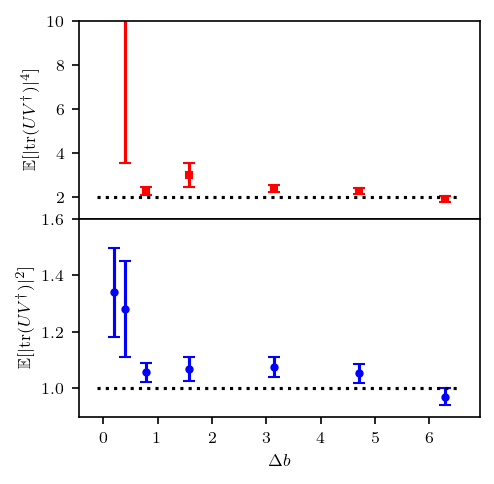

In [13]:
# make a figure 
xarr = blist
xlabel = r'$\Delta b$' 
y0low = 1; y0high = 10; y1low=0.9;y1high=1.6
ofile = froot+'bstat.png'
mk_tr_fig(Fvals_list_b,xarr,xlabel,ofile,y0low=y0low,y0high=y0high,y1low=y1low,y1high=y1high)



In [14]:
# do a series fid but varying Delta taushift, based on parms_a
# parms_a = np.array([N,N_u,a,b,eps,mu0,mup0,Delta_mu,Delta_mup,Delta_b,Delta_taushift])
#                     0 1   2 3 4   5   6     7        8        9       10
taulist = np.array([np.pi/16,np.pi/8,np.pi/4,np.pi/2,np.pi,3*np.pi/2,2*np.pi]) 
Fvals_list_c = []
seed_list_c = np.array([66,26,67,37,71,103,512,5002],dtype = int)
seed_list_c = seed_list_c[0:len(taulist)]
for k in range(len(taulist)):
    parms = np.copy(parms_a)
    parms[10] = taulist[k]
    print(taulist[k])
    Fvals = rec1(parms,seed=seed_list_c[k])
    Fvals_list_c = np.append(Fvals_list_c,Fvals)


0.19634954084936207
kone1 twosided pvalue=0.001
kone1 lower pvalue=0.000
kone1 greater pvalue=0.963
kone1 mean z =1.594 += 0.166, std z = 5.25
kone1 mean z2 =30.122 += 18.349, std z2 = 580.26

0.39269908169872414
kone1 twosided pvalue=0.322
kone1 lower pvalue=0.162
kone1 greater pvalue=0.592
kone1 mean z =1.095 += 0.042, std z = 1.34
kone1 mean z2 =2.989 += 0.449, std z2 = 14.19

0.7853981633974483
kone1 twosided pvalue=0.338
kone1 lower pvalue=0.170
kone1 greater pvalue=0.882
kone1 mean z =1.053 += 0.035, std z = 1.11
kone1 mean z2 =2.335 += 0.196, std z2 = 6.19

1.5707963267948966
kone1 twosided pvalue=0.200
kone1 lower pvalue=0.100
kone1 greater pvalue=0.422
kone1 mean z =1.063 += 0.036, std z = 1.15
kone1 mean z2 =2.448 += 0.201, std z2 = 6.35

3.141592653589793
kone1 twosided pvalue=0.243
kone1 lower pvalue=0.853
kone1 greater pvalue=0.122
kone1 mean z =1.002 += 0.040, std z = 1.25
kone1 mean z2 =2.566 += 0.594, std z2 = 18.79

4.71238898038469
kone1 twosided pvalue=0.191
kone1 lo

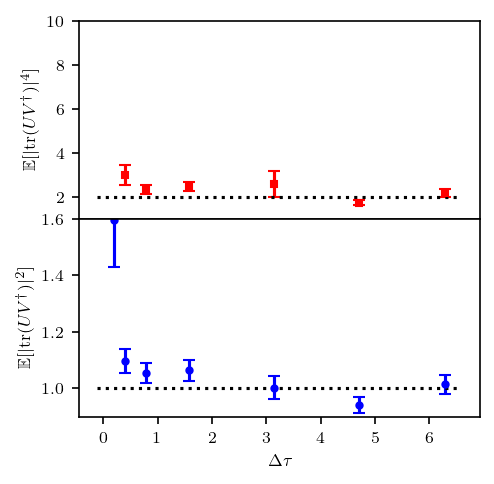

In [15]:
xarr = taulist
xlabel = r'$\Delta \tau$' 
y0low = 1; y0high = 10; y1low=0.9;y1high=1.6
ofile = froot+'taustat.png'
mk_tr_fig(Fvals_list_c,xarr,xlabel,ofile,y0low=y0low,y0high=y0high,y1low=y1low,y1high=y1high)



In [16]:
# do a series fid but varying Delta mu, based on parms_a
# parms_a = np.array([N,N_u,a,b,eps,mu0,mup0,Delta_mu,Delta_mup,Delta_b,Delta_taushift])
#                     0 1   2 3 4   5   6     7        8        9       10
mulist = np.array([0.2,0.5,1,1.5,2,2.5]) 
Fvals_list_d = []
seed_list_d = np.array([17,15,21,30001,4324,1421,59,101],dtype = int)
seed_list_d = seed_list_d[0:len(mulist)]
for k in range(len(mulist)):
    parms = np.copy(parms_a)
    parms[7] = mulist[k]
    print(mulist[k])
    Fvals = rec1(parms,seed=seed_list_d[k])
    Fvals_list_d = np.append(Fvals_list_d,Fvals)


0.2
kone1 twosided pvalue=0.000
kone1 lower pvalue=0.000
kone1 greater pvalue=0.889
kone1 mean z =1.432 += 0.108, std z = 3.41
kone1 mean z2 =13.682 += 6.609, std z2 = 209.00

0.5
kone1 twosided pvalue=0.006
kone1 lower pvalue=0.003
kone1 greater pvalue=1.000
kone1 mean z =1.109 += 0.037, std z = 1.17
kone1 mean z2 =2.596 += 0.256, std z2 = 8.11

1.0
kone1 twosided pvalue=0.204
kone1 lower pvalue=0.102
kone1 greater pvalue=0.938
kone1 mean z =1.093 += 0.038, std z = 1.19
kone1 mean z2 =2.611 += 0.245, std z2 = 7.74

1.5
kone1 twosided pvalue=0.314
kone1 lower pvalue=0.158
kone1 greater pvalue=0.728
kone1 mean z =1.058 += 0.033, std z = 1.05
kone1 mean z2 =2.221 += 0.140, std z2 = 4.43

2.0
kone1 twosided pvalue=0.718
kone1 lower pvalue=0.380
kone1 greater pvalue=0.621
kone1 mean z =1.046 += 0.042, std z = 1.32
kone1 mean z2 =2.838 += 0.598, std z2 = 18.91

2.5
kone1 twosided pvalue=0.366
kone1 lower pvalue=0.184
kone1 greater pvalue=0.971
kone1 mean z =1.071 += 0.041, std z = 1.28
kone

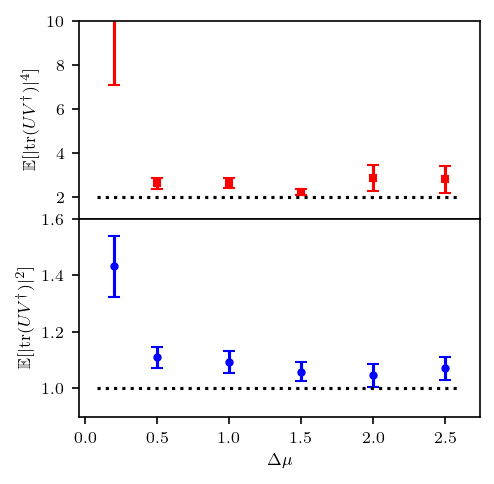

In [17]:
xarr = mulist
xlabel = r'$\Delta \mu$' 
y0low = 1; y0high = 10; y1low=0.9;y1high=1.6
ofile = froot+'mustat.png'
mk_tr_fig(Fvals_list_d,xarr,xlabel,ofile,y0low=y0low,y0high=y0high,y1low=y1low,y1high=y1high)


In [18]:
# do a series fid but varying Delta mu', based on parms_a
# parms_a = np.array([N,N_u,a,b,eps,mu0,mup0,Delta_mu,Delta_mup,Delta_b,Delta_taushift])
#                     0 1   2 3 4   5   6     7        8        9       10
muplist = np.array([0.0,0.05,0.1,0.2,0.4,0.7,1.0]) 
Fvals_list_e = []
seed_list_e = np.array([34,50,10266,5551,772,45,159,22],dtype = int)
seed_list_e = seed_list_e[0:len(muplist)]
for k in range(len(muplist)):
    parms = np.copy(parms_a)
    parms[8] = muplist[k]
    print(muplist[k])
    Fvals = rec1(parms,seed=seed_list_e[k])
    Fvals_list_e = np.append(Fvals_list_e,Fvals)


0.0
kone1 twosided pvalue=0.862
kone1 lower pvalue=0.485
kone1 greater pvalue=0.638
kone1 mean z =1.044 += 0.036, std z = 1.14
kone1 mean z2 =2.397 += 0.248, std z2 = 7.84

0.05
kone1 twosided pvalue=0.384
kone1 lower pvalue=0.867
kone1 greater pvalue=0.194
kone1 mean z =1.002 += 0.033, std z = 1.04
kone1 mean z2 =2.083 += 0.154, std z2 = 4.88

0.1
kone1 twosided pvalue=0.103
kone1 lower pvalue=0.052
kone1 greater pvalue=0.923
kone1 mean z =1.042 += 0.033, std z = 1.06
kone1 mean z2 =2.202 += 0.186, std z2 = 5.90

0.2
kone1 twosided pvalue=0.689
kone1 lower pvalue=0.811
kone1 greater pvalue=0.362
kone1 mean z =1.001 += 0.032, std z = 1.02
kone1 mean z2 =2.043 += 0.147, std z2 = 4.64

0.4
kone1 twosided pvalue=0.158
kone1 lower pvalue=0.079
kone1 greater pvalue=0.886
kone1 mean z =1.045 += 0.035, std z = 1.11
kone1 mean z2 =2.327 += 0.291, std z2 = 9.20

0.7
kone1 twosided pvalue=0.191
kone1 lower pvalue=0.905
kone1 greater pvalue=0.096
kone1 mean z =0.956 += 0.030, std z = 0.96
kone1 m

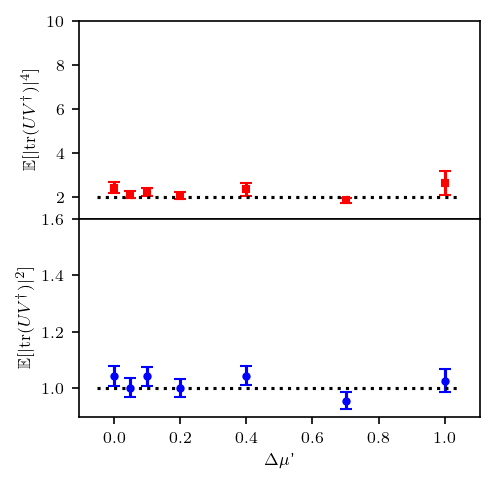

In [19]:
xarr = muplist
pstring = '\''
xlabel = r'$\Delta \mu$' + pstring 
y0low = 1; y0high = 10; y1low=0.9;y1high=1.6
ofile = froot+'mupstat.png'
mk_tr_fig(Fvals_list_e,xarr,xlabel,ofile,y0low=y0low,y0high=y0high,y1low=y1low,y1high=y1high)


In [20]:
# can we reach the same values but with fewer free parameters if we are willing to let mu, mu' be very large?

In [22]:
import pickle  # for storing python classes in binary files 
#stuff we would like to store
#parms_a, Fvals_a
#Nlist,   Fvals_list 
#blist,   Fvals_list_b
#taulist, Fvals_list_c 
#mulist,  Fvals_list_d
#muplist, Fvals_list_e 

# store these calculations!!!! 

#I stored all the matrices, it was about 1GByte, --- this would save us time if we wanted to read stuff in 
store_data = False  

if (store_data == True):
    with open('Q_bar_iter_v01_data.pkl', 'wb') as outp:   #wb means write, binary
        pickle.dump(parms_a,     outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(Fvals_a,     outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(Nlist,       outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(Fvals_list,  outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(blist,       outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(Fvals_list_b,outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(taulist,     outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(Fvals_list_c,outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(mulist,      outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(Fvals_list_d,outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(muplist,     outp, pickle.HIGHEST_PROTOCOL)
        pickle.dump(Fvals_list_e,outp, pickle.HIGHEST_PROTOCOL)

read_data = False  # if you want to read in relevant information without rerunning entire notebook
if (read_data == True):
    with open('Q_bar_iter_v01_data.pkl', 'rb') as inp:  # rb=read binary
        parms_a     = pickle.load(inp)  #FIFO
        Fvals_a     = pickle.load(inp)
        Nlist       = pickle.load(inp)
        Fvals_list  = pickle.load(inp)
        blist       = pickle.load(inp)
        Fvals_list_b= pickle.load(inp)
        taulist     = pickle.load(inp)
        Fvals_list_c= pickle.load(inp)
        mulist      = pickle.load(inp)
        Fvals_list_d= pickle.load(inp)
        muplist     = pickle.load(inp)
        Fvals_list_e= pickle.load(inp)

